<a href="https://colab.research.google.com/github/NatasaKinzy/Data-Science/blob/main/Unit8/2_NataKinzU8Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

In [ ]:
!pip install pymc-bart
import pymc_bart as pmb

# Unit 8 Project



# Context



Ok so I looked and looked for datasets. I was first going to do one on cancer and had a rough time finding a csv that would work well. Then I tried a diabetes one but it was kind of boring to me so I changed my mind. I then turned to predicting crime rates and Mr. Arradondo suggested looking at the counties dataset so here I am. Most of my causal diagram is made from assumption of what causes what. I thought it would be interesting to see what most affects homicide rates because in 7th grade I took a crime and punishment class and I'm pretty sure income, schooling, overall crime, and mental health all contribute to homicide rates so I wanted to see which contributed most.

# Purpose

I am going to try to see which variables work best at predicting homicide rates.

# Data

In [4]:
#inc for incarceration dataset
url_counties = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/counties.csv'
counties = pd.read_csv(url_counties)#.dropna()

In [5]:
counties

,name,fips,state,land_area (km^2),area (km^2),longitude (deg),latitude (deg),noaa/prcp,noaa/snow,noaa/temp,...,"industry/Agriculture, forestry, fishing and hunting/payroll","industry/Agriculture, forestry, fishing and hunting/employees",industry/Utilities/payroll,industry/Utilities/employees,industry/Management of companies and enterprises/payroll,industry/Management of companies and enterprises/employees,industry/Industries not classified/payroll,industry/Industries not classified/employees,"industry/Mining, quarrying, and oil and gas extraction/payroll","industry/Mining, quarrying, and oil and gas extraction/employees"
0,cuming county,31039,NE,1477.641638,1488.343176,-96.787366,41.916346,30.5,28.2,48.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lancaster county,31109,NE,2169.252486,2192.120047,-96.688211,40.784132,31.0,25.3,51.0,...,730000.0,111.0,8730000.0,95.0,165117000.0,2024.0,150000.0,3.0,NaN,NaN
2,nuckolls county,31129,NE,1489.645186,1491.363670,-98.047277,40.176383,27.7,22.2,51.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,keith county,31101,NE,2749.531887,2874.204062,-101.657059,41.198294,20.0,25.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,phelps county,31137,NE,1398.048570,1399.695104,-99.414593,40.513105,25.5,26.7,50.3,...,2557000.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3137,washington county,44009,RI,852.825659,1457.597303,-71.627758,41.385053,49.0,30.2,50.2,...,4339000.0,67.0,11574000.0,95.0,60844000.0,953.0,72000.0,3.0,3373000.0,44.0
3138,providence county,44007,RI,1060.791694,1128.431056,-71.569018,41.870350,52.6,46.7,49.2,...,521000.0,22.0,128342000.0,1101.0,975031000.0,11783.0,527000.0,15.0,7485000.0,97.0
3139,bristol county,44001,RI,62.513687,115.859939,-71.288552,41.704331,48.5,36.6,51.9,...,NaN,NaN,NaN,NaN,1919000.0,31.0,283000.0,4.0,NaN,NaN
3140,newport county,44005,RI,265.310311,812.295558,-71.286460,41.506366,47.4,36.6,51.6,...,1583000.0,29.0,5971000.0,75.0,10559000.0,225.0,346000.0,14.0,NaN,NaN


I need to make this dataset shorter.

# Variable Selection

In [6]:
#picking parts of the dataset I believe would contribute to homicide rates
clmn_list = ['name',
             'state',
             'population/2019',
             'health/Violent Crime Rate',
             'poverty-rate',
             'health/Average Number of Mentally Unhealthy Days',
             'health/% Excessive Drinking',
             'avg_income',
             'deaths/homicides',
             'edu/bachelors+',
             'edu/less-than-high-school',
             ]
sad_stats =  counties.loc[:,clmn_list]

In [7]:
#dropping columns/rows with any empty boxes
sdsts_nona = sad_stats.dropna()

In [8]:
#turning the number of homicides to homicides/population so I can see rates not numbers
sdsts_nona.insert(sdsts_nona.shape[1], "homicide/pop", sdsts_nona['deaths/homicides']/sdsts_nona['population/2019'])

Here I am finding homicides per population of the county because I am trying to see the rate of homicides not the number.

In [ ]:
#renaming everything I consider too long for typing
sdsts_nona.rename(columns={'edu/bachelors+':'bach+', 'health/Average Number of Mentally Unhealthy Days':'mentunhealth', 'health/% Excessive Drinking':'drinking', 'edu/less-than-high-school':'highschool-', 'health/Violent Crime Rate':'crime', 'population/2019':'pop', 'poverty-rate':'pov', 'avg_income':'income', 'homicide/pop':'homicides'}, inplace=True)

In [10]:
#seeing what final dataset looks like
sdsts_nona.head()

,name,state,pop,crime,pov,mentunhealth,drinking,income,deaths/homicides,bach+,highschool-,homicides
1,lancaster county,NE,319090,325.955385,10.7,3.826857,25.446613,49889,5.285714,39.5,6.3,0.000017
6,dakota county,NE,20026,234.146341,10.6,3.402369,18.172697,41831,0.714286,13.0,23.5,0.000036
17,scotts bluff county,NE,35618,204.782944,13.0,4.215521,18.370725,44171,0.952381,22.9,12.0,0.000027
18,adams county,NE,31363,230.589424,10.6,3.863893,23.108776,49139,0.523810,24.3,10.0,0.000017
30,douglas county,NE,571327,486.487324,10.2,3.912816,24.264965,63435,34.238095,39.7,9.4,0.000060


Ok I was just looking at this table and two of them have the same homicide rate (0.000017) and it seems like income is the most similar factor between them so I'm thinking income may be the best predictor.

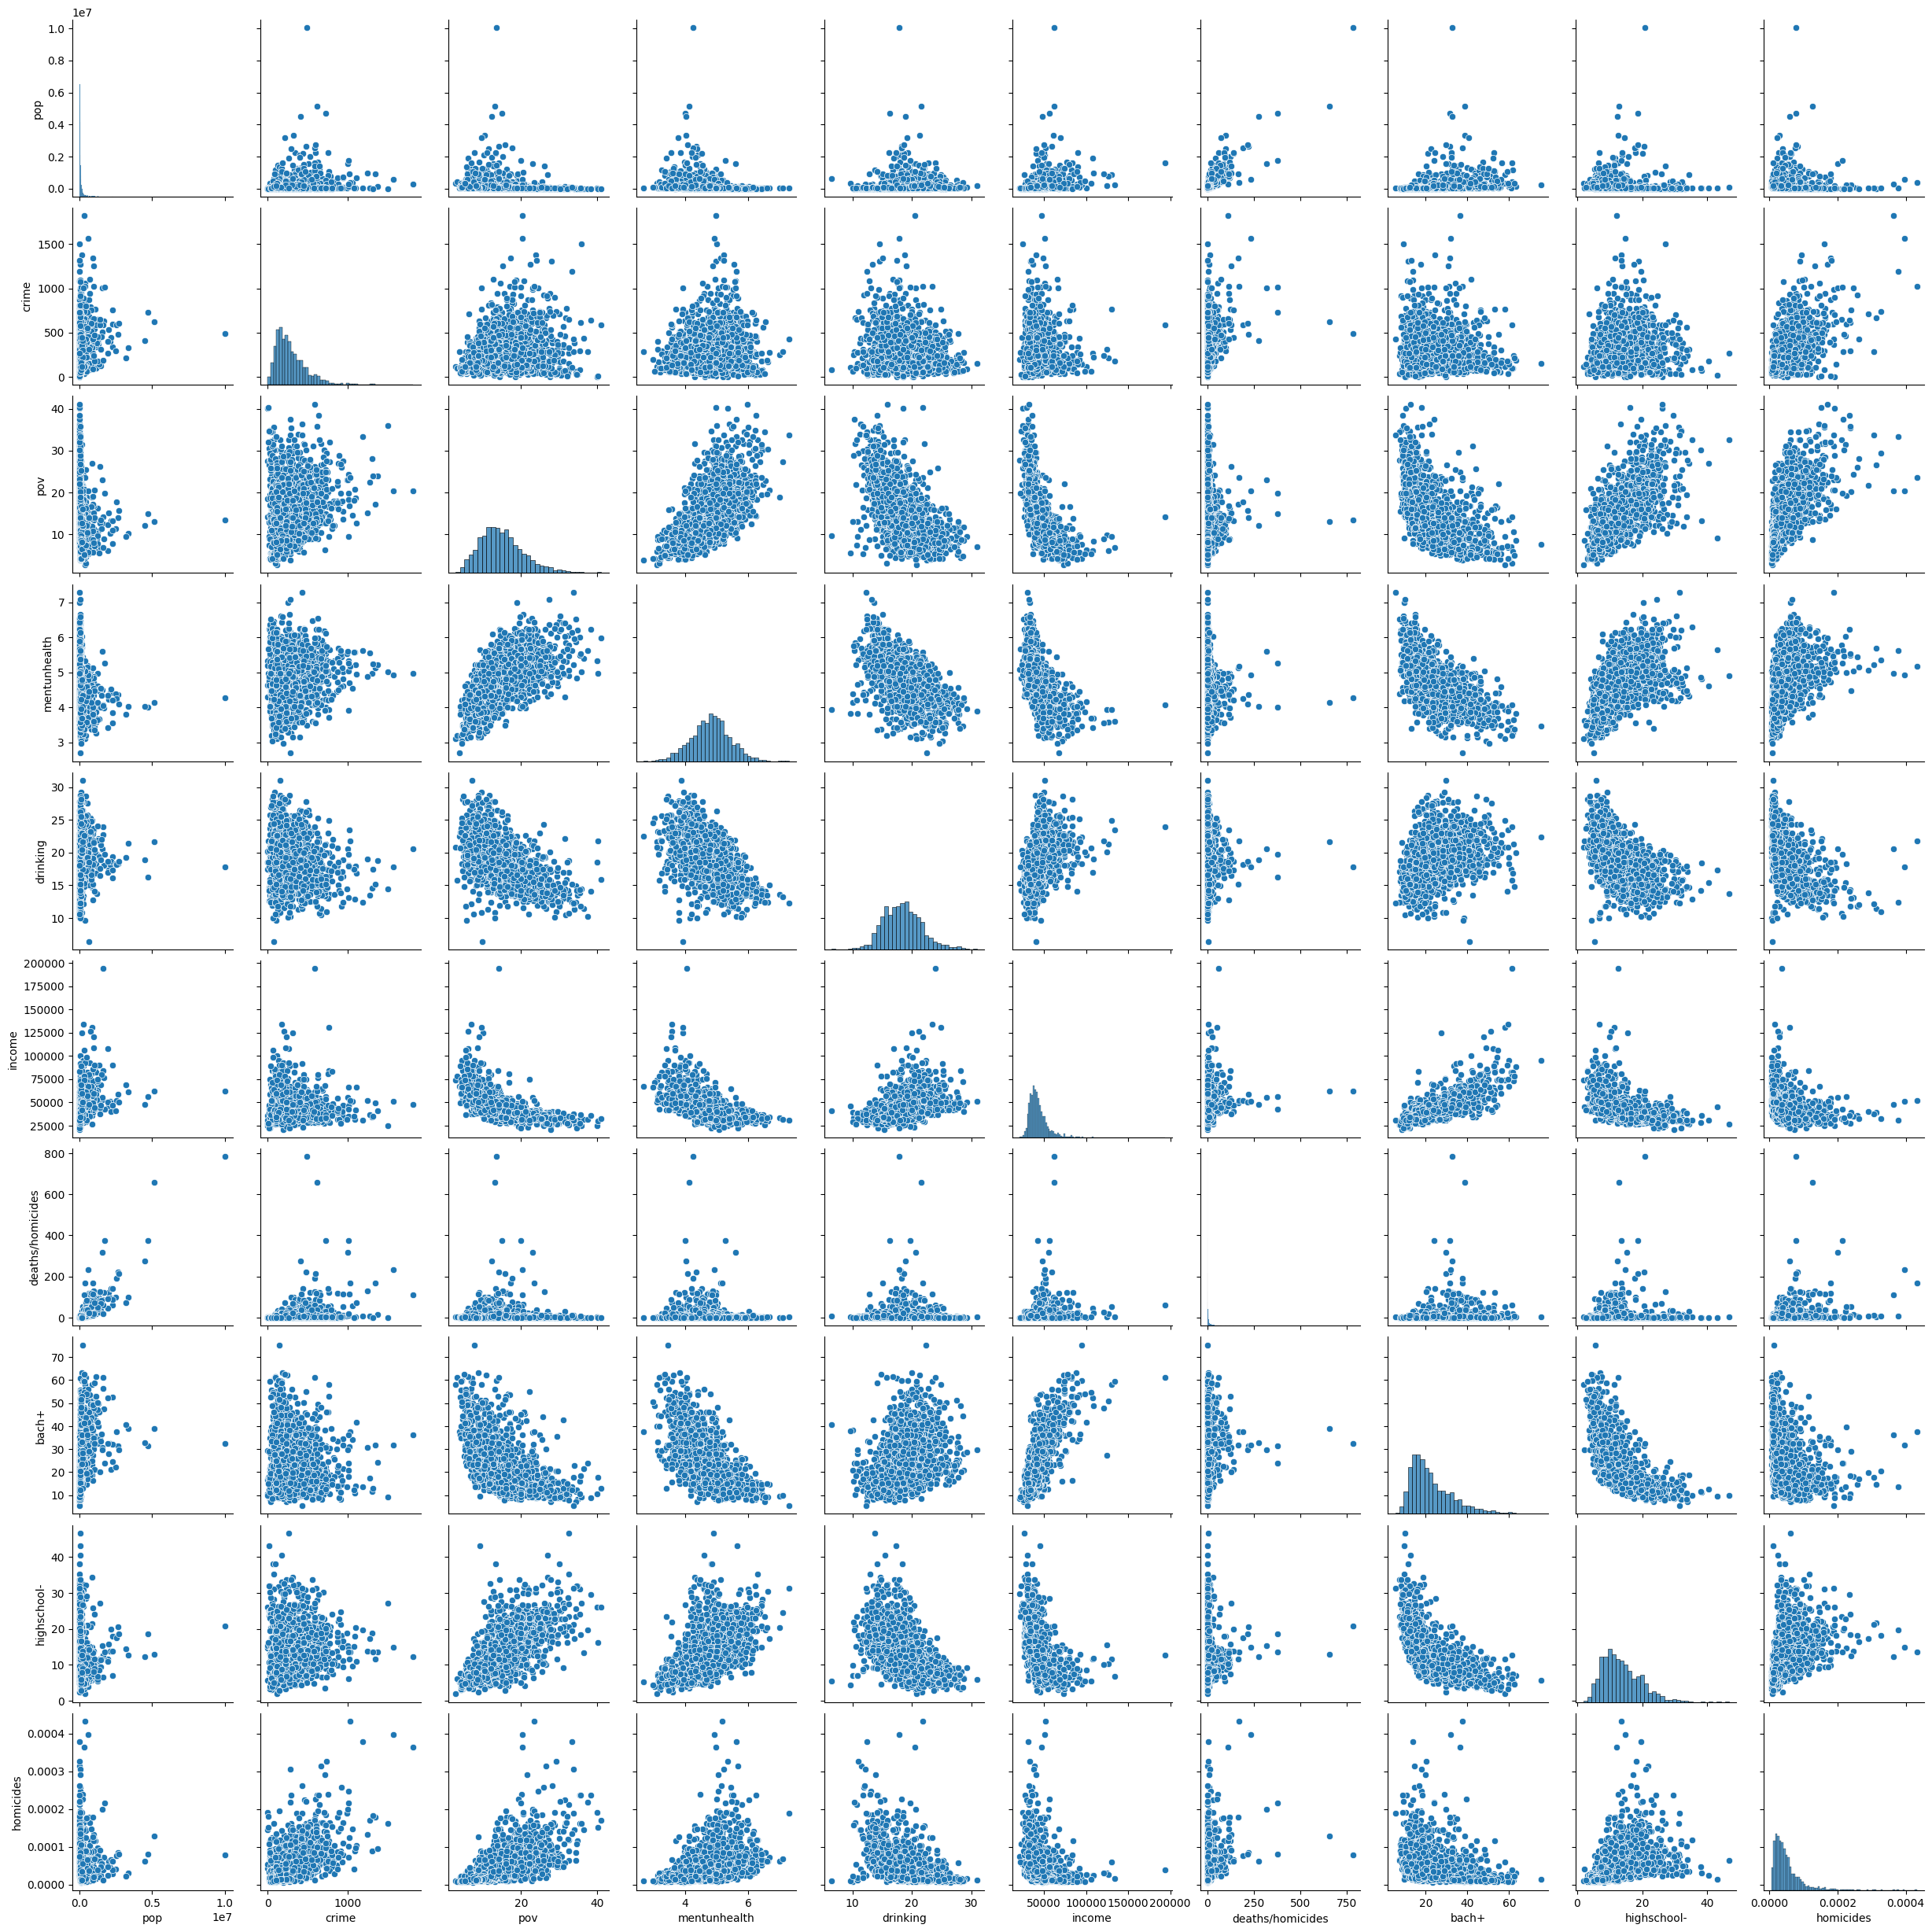

In [11]:
#pairplot to ensure data is good.
sns.pairplot(sdsts_nona)

Looking at the homicide/pop column it looks like patterns are present with every other variable.

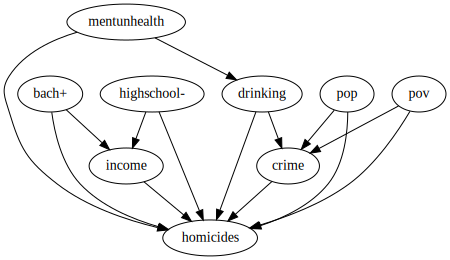

In [12]:
dag_oct = gv.Digraph(comment='oct_dag')

dag_oct.node('H', 'homicides')
dag_oct.node('M','mentunhealth')
dag_oct.node('D','drinking')
dag_oct.node('B','bach+')
dag_oct.node('S','highschool-')
dag_oct.node('P','pop')
dag_oct.node('V','pov')
dag_oct.node('C','crime')
dag_oct.node('I','income')

dag_oct.edges(['MH', 'DH', 'BH', 'SH', 'PH', 'VH', 'CH', 'IH', 'MD', 'DC', 'VC', 'PC', 'BI', 'SI'])

dag_oct

Use BART to craft our model which we'll use ice, pdps, and variable importance plots to assess.

In [23]:
features = ["income", "mentunhealth", "drinking","highschool-","crime","pop","pov","bach+"]

X = sdsts_nona[features]
Y = sdsts_nona["homicides"]

In [ ]:
with pm.Model() as model_sdsts_nona:
    s = pm.HalfNormal('s',1000)
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50)
    μ = pm.Deterministic("μ",pm.math.exp(μ_))
    y = pm.Normal("y", mu=μ, sigma=s,  observed=Y)
    idata_sdsts_nona = pm.sample(compute_convergence_checks=False)

In [ ]:
pm.sample_posterior_predictive(idata_sdsts_nona, model_sdsts_nona, extend_inferencedata=True)

<Axes: xlabel='y'>

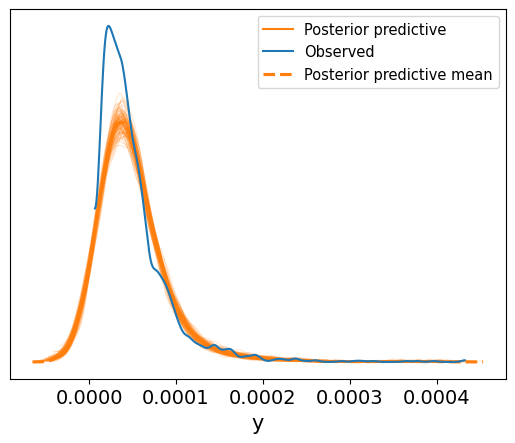

In [26]:
az.plot_ppc(idata_sdsts_nona, num_pp_samples=100, colors=["C1", "C0", "C1"])

In [27]:
posterior_mean = idata_sdsts_nona.posterior["μ"]

μ_hdi = az.hdi(ary=idata_sdsts_nona, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_sdsts_nona, group="posterior_predictive", var_names=["y"]
).T

Now lets assess this model with the pdp, ice, and vi plots.

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='income'>, <Axes: xlabel='mentunhealth'>,
       <Axes: xlabel='drinking'>, <Axes: xlabel='highschool-'>,
       <Axes: xlabel='crime'>, <Axes: xlabel='pop'>, <Axes: xlabel='pov'>,
       <Axes: xlabel='bach+'>], dtype=object)

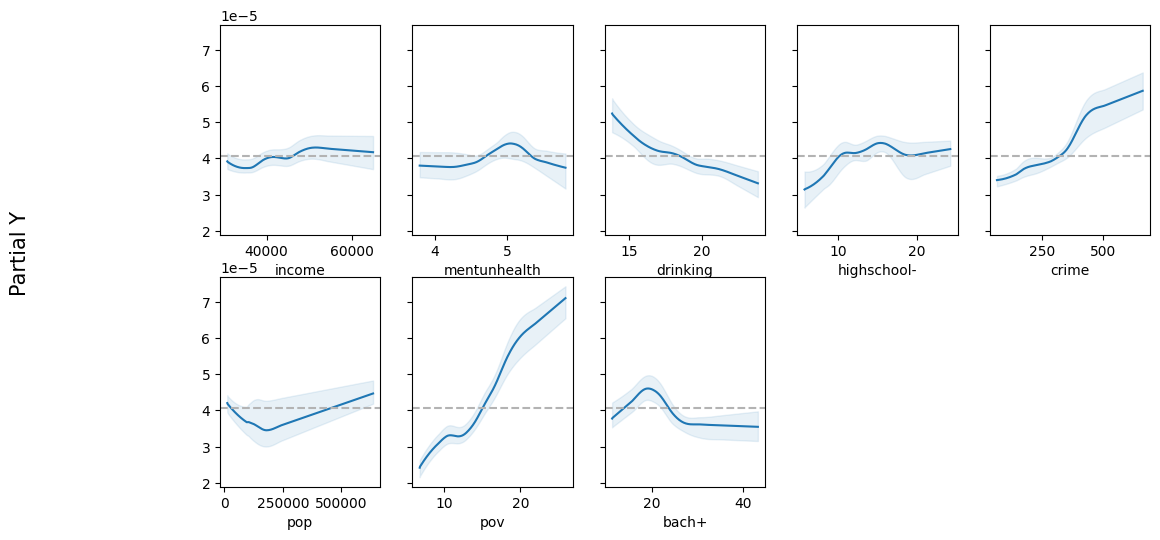

In [28]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

/usr/local/lib/python3.12/dist-packages/pymc_bart/utils.py:494: UserWarning: The grid is smaller than the number of available variables to plot.
                Automatically adjusting the grid size.
  warnings.warn(


array([<Axes: xlabel='income'>, <Axes: xlabel='mentunhealth'>,
       <Axes: xlabel='drinking'>, <Axes: xlabel='highschool-'>,
       <Axes: xlabel='crime'>, <Axes: xlabel='pop'>, <Axes: xlabel='pov'>,
       <Axes: xlabel='bach+'>], dtype=object)

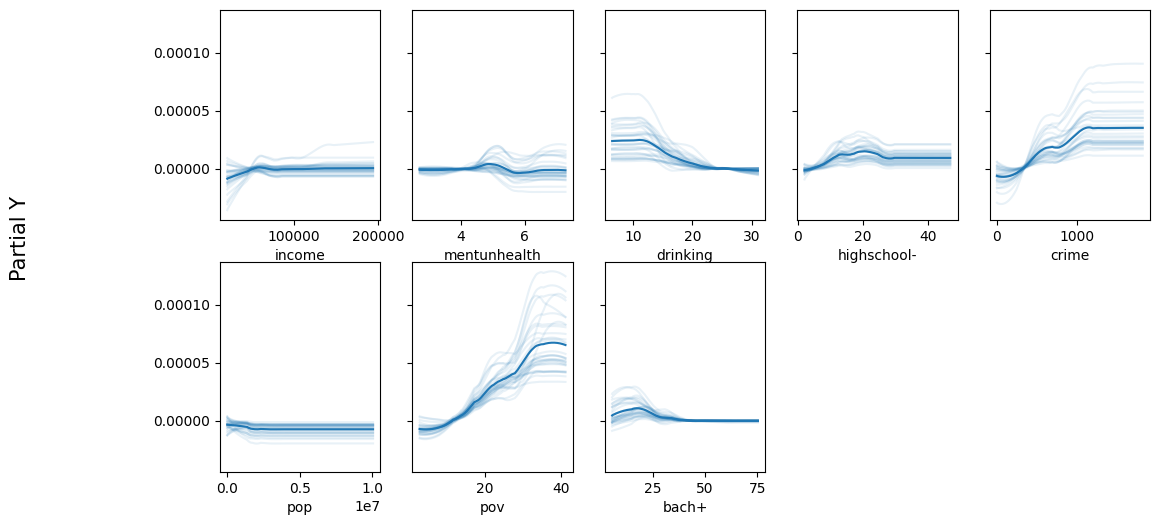

In [29]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

# Analysis

Here it seems like poverty has the most prevalent pattern and impact on homicide rate. However, as more of the population is impovrished, the direct association is less certain (there is more variance).

Crime pretty obviously impacts homicides but it seems to have a capped out impact past 1000 which is interesting.

Having less than a highschool education seems to impact homicides a bit from the 5-30% range but it seems to have a capped out influence after that as well.

Having a bachelors degree and above impacts homicide rate when there is less than 25% of the population with a bachelors and above degree. I think this could be because having a population where only 1/4 have a bachelors+ would usually indicate that population is also more impovrished than others.

Population seems to have little to no impact on homicide rate.

The amount of mentally unhealthy days people take has much more of an impact (but still not that much of an impact) on homicides past about 4 days but its a pretty uncertain/wavy pattern.

Incomes below around 50,000 seem to have some affect on homicide rate (that's very close to the poverty line) but after 50,000 it has virtually no affect.

Interesting the lower the % of excessive drinking seems to relate to homicides more than a greater % which doesn't make sense to me because I would've thought more drinking would result in more killings. Maybe it is because it is % of the population who excessively drink so the less of the population that do it the more radical/roudy/unusual they can be.

In [30]:
vi_penguins = pmb.compute_variable_importance(idata_sdsts_nona, μ_, X)

<Axes: ylabel='R²'>

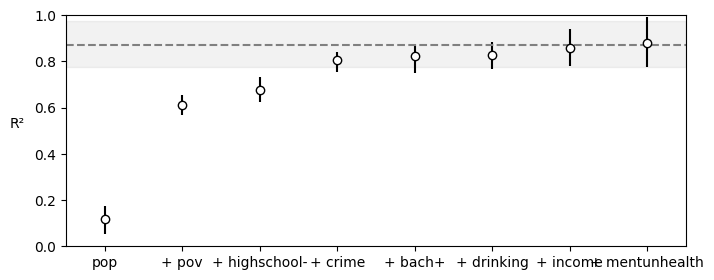

In [31]:
pmb.plot_variable_importance(vi_penguins)

This VI plot goes along with our ice plot and shows the largest jump with poverty rate so that gives me more confidence that poverty rate is the best predictor.

# Conclusion

Based on all of these plots I believe that poverty is the best predictor for homicide rate.

I am surprised population and income had so little bearing since I had imagined the greater the income the lower homicide rate and the greater the population the higher the homicide rate. However I realize now it's homicide rate not number so it actually makes complete sense population has no effect.

I also thought drinking and mentally unhealthy days would do more but aparently they are only bad/ok predictors.  

I was glad to find bachelors+ degrees did have an affect at least when the percent of population with them was lower because as far as I know the more education you have supposedly the fewer bad things you do (not certain I've just heard this around) so I was glad to see it had a small impact on homicide rate.